# **Day 87: A Google Earth Engine (and STAC) Data Pipeline for ML**
*Module 13 - Remote Sensing ML and Publication Projects*

Real projects need real imagery. **Google Earth Engine (GEE)** hosts petabytes of analysis-ready data (Sentinel-1/2, Landsat, MODIS, DEMs, climate) and computes on Google's servers. The standard RS-ML workflow is:

**GEE**: filter collections -> mask clouds -> composite -> compute features -> sample at field points -> **export a training table** (and the feature stack) -> **train in Python** (Days 15-85) -> predict -> export the map.

Today we get the complete, reusable GEE code for this workflow, an equivalent using open **STAC** catalogues (Microsoft Planetary Computer), and an **offline** run of the same steps on the GeoTIFFs from Day 86, so the notebook executes anywhere.

> Google Earth Engine stores petabytes of satellite data and processes it on Google's servers. A typical pipeline filters images, removes clouds, makes seasonal composites, computes indices and exports a training table for ML in Python.
>
> *Example:* Instead of downloading 200 Sentinel-2 scenes, one Earth Engine script builds a cloud-free monsoon median composite of the district in minutes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio, geopandas as gpd, warnings
from pathlib import Path
import rs_utils as ru
DATA = Path("data/study_area")
USE_GEE = False          # set True after `pip install earthengine-api geemap` and `earthengine authenticate`
USE_STAC = False         # set True after `pip install pystac-client planetary-computer odc-stac`

## **1. Setup and Authentication**
1. Register a Google Cloud project for Earth Engine (free for research and education): code.earthengine.google.com/register
2. `pip install earthengine-api geemap`
3. In Python: `ee.Authenticate()` once, then `ee.Initialize(project="your-cloud-project-id")`.

In [2]:
if USE_GEE:
    import ee, geemap
    ee.Initialize(project="your-cloud-project-id")
    # Area of interest: the 10 x 10 km study area of Day 86 (UTM 45N), or any polygon / shapefile
    aoi = ee.Geometry.Rectangle([430000, 2630000, 440000, 2640000], proj="EPSG:32645", geodesic=False)
    START, END = "2024-01-01", "2024-12-31"

## **2. Sentinel-2: Cloud Masking and Seasonal Composites**
Use the **harmonized** surface reflectance collection (consistent radiometry across the 2022 processing-baseline change) and **Cloud Score+** (a per-pixel cloud/shadow quality score) to mask clouds. Then compute **seasonal median composites**: the most common, robust approach for land-cover ML.

In [3]:
if USE_GEE:
    BANDS = ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12"]
    cs_plus = ee.ImageCollection("GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED")
    def s2_collection(start, end, cs_threshold=0.6):
        return (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
                .filterBounds(aoi).filterDate(start, end)
                .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 60))
                .linkCollection(cs_plus, ["cs_cdf"])
                .map(lambda img: img.updateMask(img.select("cs_cdf").gte(cs_threshold)).select(BANDS).divide(10000)))
    def add_indices(img):
        ndvi = img.normalizedDifference(["B8", "B4"]).rename("NDVI")
        mndwi = img.normalizedDifference(["B3", "B11"]).rename("MNDWI")
        ndbi = img.normalizedDifference(["B11", "B8"]).rename("NDBI")
        ndre = img.normalizedDifference(["B8A", "B5"]).rename("NDRE")
        return img.addBands([ndvi, mndwi, ndbi, ndre])
    seasons = {"winter": ("2024-01-01", "2024-02-29"), "premonsoon": ("2024-03-01", "2024-05-31"),
               "monsoon": ("2024-06-01", "2024-09-30"), "postmonsoon": ("2024-10-01", "2024-12-31")}
    composites = [add_indices(s2_collection(*rng_).median()).rename([f"{s}_{b}" for b in BANDS + ["NDVI", "MNDWI", "NDBI", "NDRE"]])
                  for s, rng_ in seasons.items()]
    s2_stack = ee.Image.cat(composites).clip(aoi)
    print("Sentinel-2 images per season:", {s: s2_collection(*r).size().getInfo() for s, r in seasons.items()})

## **3. Sentinel-1 and Terrain**

In [4]:
if USE_GEE:
    s1 = (ee.ImageCollection("COPERNICUS/S1_GRD").filterBounds(aoi).filterDate(START, END)
          .filter(ee.Filter.eq("instrumentMode", "IW"))
          .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
          .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
          .filter(ee.Filter.eq("orbitProperties_pass", "ASCENDING"))          # keep one geometry for consistency
          .select(["VV", "VH"]))
    s1_stack = ee.Image.cat([s1.filterDate(*seasons["monsoon"]).median().rename(["monsoon_VV", "monsoon_VH"]),
                             s1.filterDate(*seasons["winter"]).median().rename(["winter_VV", "winter_VH"])]).clip(aoi)
    dem = ee.ImageCollection("COPERNICUS/DEM/GLO30").filterBounds(aoi).select("DEM").mosaic().setDefaultProjection("EPSG:4326", None, 30)
    terrain = ee.Terrain.products(dem).select(["DEM", "slope", "aspect"]).rename(["elevation", "slope", "aspect"]).clip(aoi)
    feature_stack = ee.Image.cat([s2_stack, s1_stack, terrain]).toFloat()
    print("number of features:", feature_stack.bandNames().size().getInfo())

## **4. Sampling at Field Points and Exporting**
Upload field points (`geemap.geopandas_to_ee` or as an Asset), sample the stack, and **export** the table. Always set `scale` (and a `projection` for exported images), use `tileScale` for heavy computations, and export long jobs rather than calling `getInfo()`.

In [5]:
if USE_GEE:
    field = gpd.read_file(DATA / "field_points.gpkg").to_crs("EPSG:4326")
    points = geemap.geopandas_to_ee(field[["point_id", "class_id", "geometry"]])
    samples = feature_stack.sampleRegions(collection=points, properties=["point_id", "class_id"], scale=10, tileScale=4, geometries=True)
    ee.batch.Export.table.toDrive(collection=samples, description="training_table_2024", folder="gee_exports", fileFormat="CSV").start()
    ee.batch.Export.image.toDrive(image=feature_stack, description="feature_stack_2024", folder="gee_exports", region=aoi,
                                  scale=10, crs="EPSG:32645", maxPixels=1e10, fileFormat="GeoTIFF").start()
    # Stratified random reference sample from an existing map (e.g. ESA WorldCover) for photo-interpretation:
    worldcover = ee.ImageCollection("ESA/WorldCover/v200").first().clip(aoi)
    strat = worldcover.stratifiedSample(numPoints=100, classBand="Map", region=aoi, scale=10, seed=42, geometries=True)

## **5. Classify Inside GEE, or Export to Python?**

| | Inside GEE (`ee.Classifier.smileRandomForest`) | Export -> Python |
|---|---|---|
| Scale | whole countries, no downloads | needs download / tiling (Day 84) |
| Models | RF, CART, SVM, gradient boosting, naive Bayes, kNN | **anything** (XGBoost, deep learning, conformal, SHAP) |
| Validation | basic error matrix | spatial CV, statistical tests, area estimation (Day 88) |
| Reproducibility | script + asset IDs | full control |

A common hybrid: tune and validate properly in Python, then **train the final RF in GEE** with the chosen settings to map large areas.

In [6]:
if USE_GEE:
    bands = feature_stack.bandNames()
    training = samples.randomColumn("rand", 42)
    clf = ee.Classifier.smileRandomForest(numberOfTrees=300, variablesPerSplit=8, minLeafPopulation=2, seed=42) \
            .train(features=training.filter(ee.Filter.lt("rand", 0.7)), classProperty="class_id", inputProperties=bands)
    classified = feature_stack.classify(clf).clip(aoi)
    em = training.filter(ee.Filter.gte("rand", 0.7)).classify(clf).errorMatrix("class_id", "classification")
    print("holdout accuracy (random split - see Day 88 for why this is optimistic):", em.accuracy().getInfo())
    Map = geemap.Map(); Map.centerObject(aoi, 13)
    Map.addLayer(s2_stack, {"bands": ["monsoon_B8", "monsoon_B4", "monsoon_B3"], "min": 0, "max": 0.4}, "S2 monsoon false colour")
    Map.addLayer(classified, {"min": 0, "max": 5, "palette": ru.LC_COLORS}, "RF land cover"); Map

## **6. The Open Alternative: STAC + Microsoft Planetary Computer**
**STAC** (SpatioTemporal Asset Catalog) is the open standard for searching imagery. Planetary Computer serves Sentinel-1/2, Landsat and more as Cloud-Optimised GeoTIFFs that load lazily into Xarray (Day 84).

In [7]:
if USE_STAC:
    import pystac_client, planetary_computer, odc.stac
    catalog = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1", modifier=planetary_computer.sign_inplace)
    search = catalog.search(collections=["sentinel-2-l2a"], bbox=[86.31, 23.76, 86.41, 23.85], datetime="2024-09-01/2024-09-30",
                            query={"eo:cloud_cover": {"lt": 20}})
    items = search.item_collection()
    ds = odc.stac.load(items, bands=["B04", "B08", "SCL"], crs="EPSG:32645", resolution=10, bbox=[86.31, 23.76, 86.41, 23.85], chunks={})
    clear = ds.SCL.isin([4, 5, 6, 7, 11])                                     # vegetation, bare, water, unclassified, snow
    ndvi_median = ((ds.B08 - ds.B04) / (ds.B08 + ds.B04)).where(clear).median("time").compute()

## **7. The Same Pipeline Offline (Runs Here)**
We reproduce the GEE logic on the Day 86 GeoTIFFs: cloud-mask -> seasonal composites -> indices -> stack with S1 and terrain -> sample at field points -> export CSV and a feature-stack GeoTIFF. Days 89-91 use these outputs.

In [8]:
with rasterio.open(DATA / "s2_2024_stack.tif") as src:
    s2 = src.read().astype(np.float32).reshape(6, 10, src.height, src.width) / 10000; profile = src.profile; T = src.transform
with rasterio.open(DATA / "s2_2024_cloudmask.tif") as src: clouds = src.read().astype(bool)
with rasterio.open(DATA / "s1_2024_vv_vh_db.tif") as src: s1 = src.read().reshape(6, 2, src.height, src.width)
with rasterio.open(DATA / "terrain.tif") as src: terrain = src.read(); terrain_names = list(src.descriptions)
H, W = s2.shape[2:]
s2[np.repeat(clouds[:, None], 10, axis=1)] = np.nan                                          # cloud masking
season_dates = {"winter": [0], "premonsoon": [1, 2], "monsoon": [3, 4], "postmonsoon": [5]}  # date indices: Jan, Mar, May, Jul, Sep, Nov
layers, names = [], []
for season, di in season_dates.items():
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)                                       # pixels cloudy on every date -> NaN gap
        comp = np.nanmedian(s2[di], axis=0)                                                   # median composite (nan-aware)
    b = dict(zip(ru.S2_BANDS, comp))
    for k, v in {**b, **{k_: v_ for k_, v_ in ru.indices(b).items() if k_ in ("NDVI", "MNDWI", "NDBI", "NDRE", "BSI")}}.items():
        layers.append(v); names.append(f"{season}_{k}")
for season, di in [("monsoon", [3, 4]), ("winter", [0])]:
    for p, pol in enumerate(["VV", "VH"]):
        layers.append(np.mean(s1[di, p], axis=0)); names.append(f"{season}_{pol}")
for i, n_ in enumerate(terrain_names[:3]):
    layers.append(terrain[i]); names.append(n_)
stack = np.stack(layers).astype(np.float32)
print(f"feature stack: {stack.shape[0]} layers | missing (cloud-gap) fraction: {np.isnan(stack).mean():.4f}")
ru.write_geotiff(DATA / "feature_stack_2024.tif", stack, T, nodata=np.nan, band_names=names)
pd.Series(names).to_csv(DATA / "feature_names.csv", index=False, header=["feature"])
print("wrote", DATA / "feature_stack_2024.tif", f"({(DATA / 'feature_stack_2024.tif').stat().st_size / 1e6:.1f} MB)")

feature stack: 67 layers | missing (cloud-gap) fraction: 0.0107


wrote data\study_area\feature_stack_2024.tif (53.7 MB)


In [9]:
field = gpd.read_file(DATA / "field_points.gpkg")
with rasterio.open(DATA / "feature_stack_2024.tif") as src:
    vals = np.array(list(src.sample([(p.x, p.y) for p in field.geometry])))
table = pd.concat([field[["point_id", "class_id", "class"]].reset_index(drop=True), pd.DataFrame(vals, columns=names)], axis=1)
table["x"], table["y"] = field.geometry.x.values, field.geometry.y.values
table.to_csv(DATA / "training_table_seasonal.csv", index=False)
print(table.shape); table[["class", "monsoon_NDVI", "winter_NDVI", "monsoon_VH", "elevation_m"]].groupby("class").median().round(3)

(600, 72)


,monsoon_NDVI,winter_NDVI,monsoon_VH,elevation_m
class,,,,
built_up,0.159,0.176,-12.325000,243.391998
cropland,0.498,0.470,-20.048000,259.509003
forest,0.677,0.639,-14.301000,430.479004
mining_bare,0.096,0.092,-19.351999,338.903015
shrub_grass,0.476,0.366,-16.469000,276.996002
water,-0.085,-0.044,-28.395000,197.998001


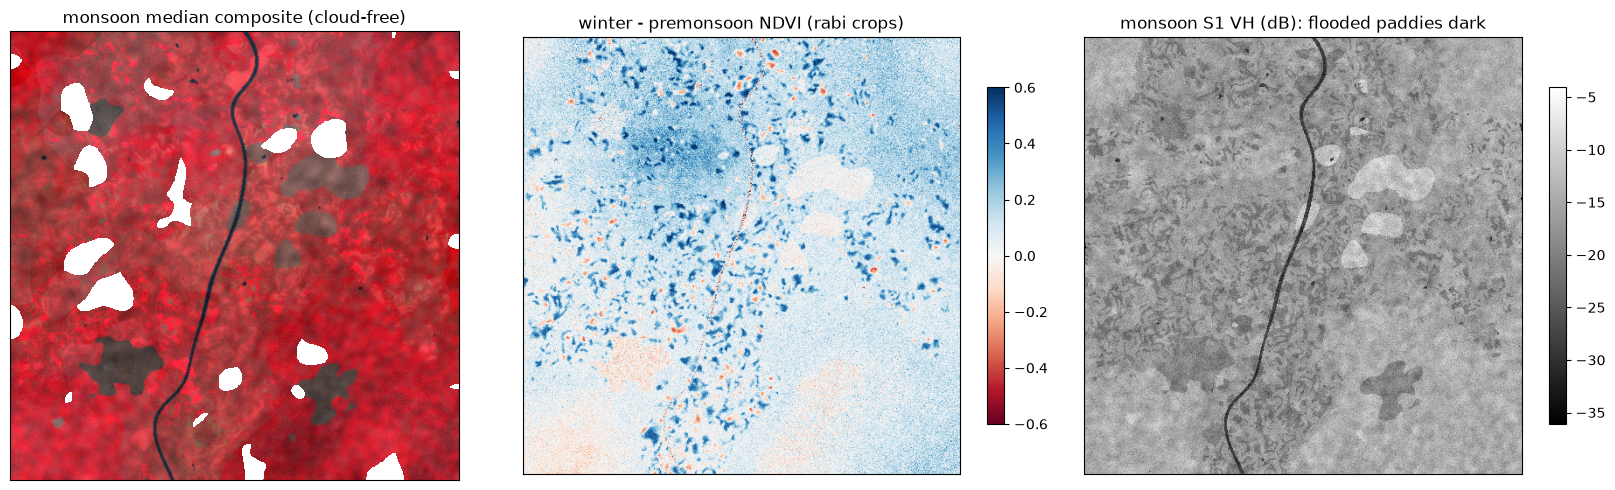

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
pick = lambda n_: stack[names.index(n_)]
axes[0].imshow(np.clip(np.dstack([pick("monsoon_B8"), pick("monsoon_B4"), pick("monsoon_B3")]) / 0.4, 0, 1)); axes[0].set_title("monsoon median composite (cloud-free)")
im = axes[1].imshow(pick("winter_NDVI") - pick("premonsoon_NDVI"), cmap="RdBu", vmin=-0.6, vmax=0.6); axes[1].set_title("winter - premonsoon NDVI (rabi crops)"); fig.colorbar(im, ax=axes[1], shrink=0.75)
im = axes[2].imshow(pick("monsoon_VH"), cmap="gray"); axes[2].set_title("monsoon S1 VH (dB): flooded paddies dark"); fig.colorbar(im, ax=axes[2], shrink=0.75)
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

# **Part 2: Good Practice for Reproducible GEE Work**

- **Pin everything**: collection IDs (e.g. `COPERNICUS/S2_SR_HARMONIZED`), date ranges, cloud thresholds, scale, CRS; store field points as a versioned Asset.
- **Do not `getInfo()` large objects**; export instead. Use `tileScale` for memory errors, `bestEffort` sparingly.
- **Scale matters**: `sampleRegions(scale=10)` samples at 10 m; a `reduceRegion` without scale uses the default projection (often 1 degree for computed images): a classic silent error.
- **Projection of composites**: a median composite has no native projection; set `crs`/`scale` explicitly on export.
- **Harmonised collections** remove the 2022 Sentinel-2 offset; Landsat Collection 2 Level-2 needs `* 0.0000275 - 0.2` scaling.
- **Report** in our paper: collections, dates, cloud masking method and threshold, compositing method, number of images per pixel, export scale and CRS.

## **Practice Problems**
1. Add a **cloud-free observation count** layer (number of valid dates per pixel) to the offline stack. Where is it lowest?
2. Add the **standard deviation** of NDVI over all dates as a feature (a proxy for cropping intensity).
3. *(GEE)* Write the code to export a 10 m feature stack for a district polygon read from a shapefile, tiled into 4 exports.
4. *(Advanced)* Compare `nanmedian` and `nanmean` composites for the monsoon season. Which is more robust to residual cloud edges?

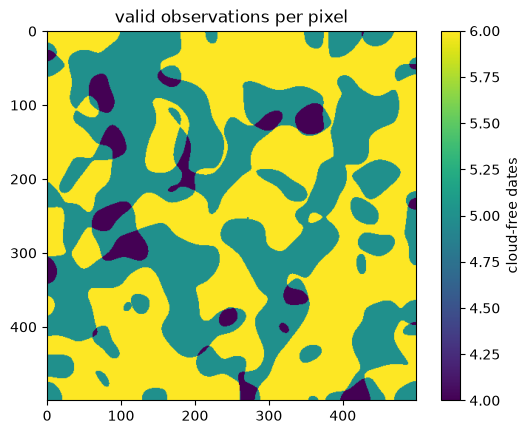

min / max valid dates: 4 6
median NDVI s.d. by true class: {'water': 0.139, 'forest': 0.097, 'cropland': 0.146, 'built_up': 0.048, 'mining_bare': 0.069, 'shrub_grass': 0.105}
nanmedian annual NIR composite: mean abs. error 0.0004, 99th percentile 0.0101
nanmean   annual NIR composite: mean abs. error 0.0081, 99th percentile 0.0483


In [11]:
# Solution 1
valid_count = (~np.isnan(s2[:, 6])).sum(0)
plt.imshow(valid_count, cmap="viridis"); plt.colorbar(label="cloud-free dates"); plt.title("valid observations per pixel"); plt.show()
print("min / max valid dates:", int(valid_count.min()), int(valid_count.max()))
# Solution 2
ndvi_all = (s2[:, 6] - s2[:, 2]) / (s2[:, 6] + s2[:, 2])
ndvi_sd = np.nanstd(ndvi_all, axis=0)
print("median NDVI s.d. by true class:", {c: round(float(np.nanmedian(ndvi_sd[rasterio.open(DATA / '_truth_landcover_SIMULATION_ONLY.tif').read(1) == k])), 3) for k, c in enumerate(ru.LC_CLASSES)})
# Solution 4: residual cloud contamination = a 3-pixel bright ring that the cloud mask misses
from scipy.ndimage import binary_dilation
nir_clean = s2[:, 6].copy()                                                                  # cloud-masked NIR, all 6 dates
nir_dirty = nir_clean.copy()
for t in range(6):
    ring = binary_dilation(clouds[t], iterations=3) & ~clouds[t]
    nir_dirty[t][ring] += 0.15                                                               # thin cloud / shadow edge not masked
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    ref = np.nanmedian(nir_clean, 0)
    for nm, f in [("nanmedian", np.nanmedian), ("nanmean", np.nanmean)]:
        err = np.abs(f(nir_dirty, 0) - ref)
        print(f"{nm:<9} annual NIR composite: mean abs. error {np.nanmean(err):.4f}, 99th percentile {np.nanpercentile(err, 99):.4f}")

**Solution 3 (GEE sketch):**
```python
district = geemap.shp_to_ee("district.shp").geometry()
grid = district.coveringGrid(ee.Projection("EPSG:32645").atScale(20000))       # 20 km tiles
for i, tile in enumerate(grid.toList(grid.size()).getInfo()):
    ee.batch.Export.image.toDrive(feature_stack.clip(district), description=f"stack_tile_{i}", region=ee.Feature(tile).geometry(),
                                  scale=10, crs="EPSG:32645", maxPixels=1e10).start()
```

## **Key References**
- Gorelick, N. et al. (2017). Google Earth Engine: Planetary-scale geospatial analysis for everyone. *Remote Sensing of Environment*, 202, 18-27.
- Pasquarella, V. J., Brown, C. F., Czerwinski, W., & Rucklidge, W. J. (2023). Comprehensive quality assessment of optical satellite imagery using weakly supervised video learning. *CVPR Workshops 2023* (Cloud Score+).
- Wu, Q. (2020). geemap: A Python package for interactive mapping with Google Earth Engine. *Journal of Open Source Software*, 5(51), 2305.
- Zanaga, D. et al. (2022). ESA WorldCover 10 m 2021 v200. Zenodo. doi:10.5281/zenodo.7254221.
- Phan, T. N., Kuch, V., & Lehnert, L. W. (2020). Land cover classification using Google Earth Engine and random forest classifier - the role of image composition. *Remote Sensing*, 12(15), 2411.
- Tamiminia, H. et al. (2020). Google Earth Engine for geo-big data applications: A meta-analysis and systematic review. *ISPRS Journal of Photogrammetry and Remote Sensing*, 164, 152-170.